In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
plt.style.use('ggplot')

In [152]:
df = pd.read_excel(f"marketing_campaign.xlsx")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [153]:
df.shape

(2240, 29)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [155]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


In [156]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [157]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [158]:
df.duplicated().sum()

np.int64(0)

In [159]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Customer_Tenure'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [160]:
df['Age'] = 2026 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts',
                            'MntGoldProds']].sum(axis=1)

In [161]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Customer_Tenure', 'Age', 'Total_Children', 'Total_Spending'],
      dtype='object')

In [162]:
print('number of unique values ')
print(f'Education : {df['Education'].nunique()}')
print(f'Marital_Status : {df['Marital_Status'].nunique()}')

number of unique values 
Education : 5
Marital_Status : 8


In [163]:
x = pd.get_dummies(df['Education'], prefix='Education', dtype = int)
df = pd.concat([df,x],axis = 1)
# df.drop('Education',axis = 1, inplace = True)

In [164]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

In [165]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Customer_Tenure,Age,Total_Children,Total_Spending,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,1957,Graduation,4,58138.0,0,0,2012-09-04,58,635,...,1,663,69,0,1617,0,0,1,0,0
1,2174,1954,Graduation,4,46344.0,1,1,2014-03-08,38,11,...,0,113,72,2,27,0,0,1,0,0
2,4141,1965,Graduation,5,71613.0,0,0,2013-08-21,26,426,...,0,312,61,0,776,0,0,1,0,0
3,6182,1984,Graduation,5,26646.0,1,0,2014-02-10,26,11,...,0,139,42,1,53,0,0,1,0,0
4,5324,1981,PhD,3,58293.0,1,0,2014-01-19,94,173,...,0,161,45,1,422,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,3,61223.0,0,1,2013-06-13,46,709,...,0,381,59,1,1341,0,0,1,0,0
2236,4001,1946,PhD,5,64014.0,2,1,2014-06-10,56,406,...,0,19,80,3,444,0,0,0,0,1
2237,7270,1981,Graduation,2,56981.0,0,0,2014-01-25,91,908,...,0,155,45,0,1241,0,0,1,0,0
2238,8235,1956,Master,5,69245.0,0,1,2014-01-24,8,428,...,0,156,70,1,843,0,0,0,1,0


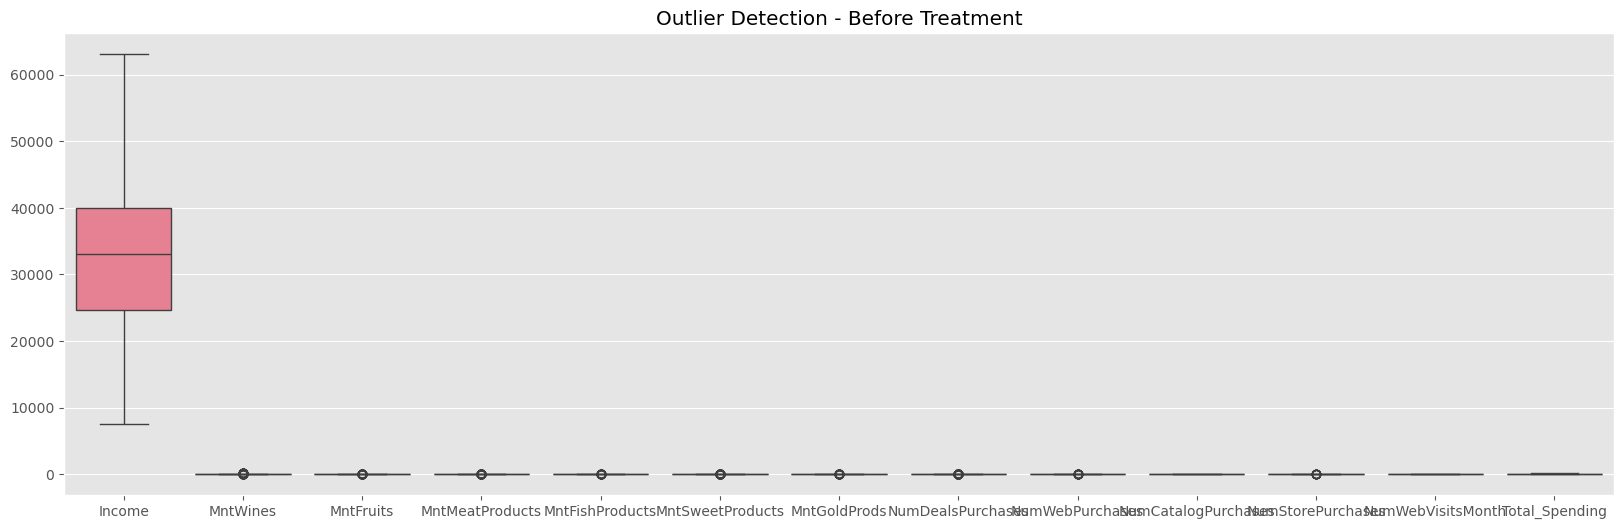

In [191]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df[['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']])
plt.title("Outlier Detection - Before Treatment")
plt.show()

In [192]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = np.where(data[column]>upper,upper,np.where(data[column]<lower,lower,data[column]))
    return data

for col in ['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']:
    df = remove_outliers_iqr(df, col)

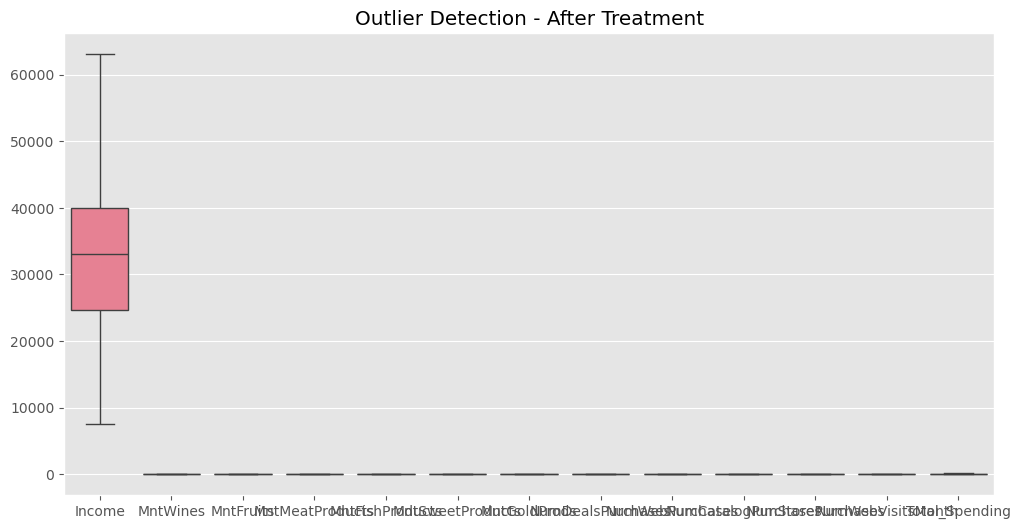

In [193]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']])
plt.title("Outlier Detection - After Treatment")
plt.show()

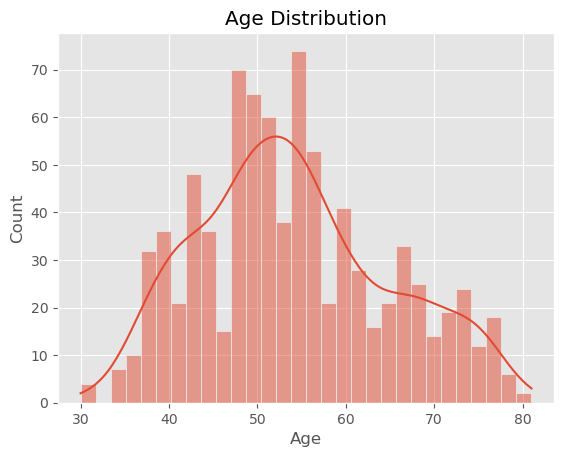

In [194]:
sns.histplot(df['Age'], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

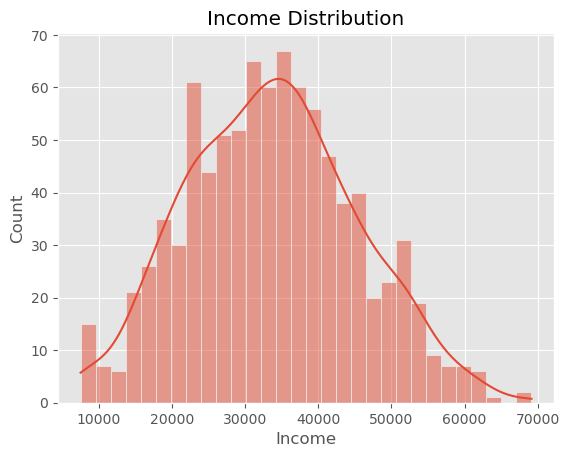

In [170]:
sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

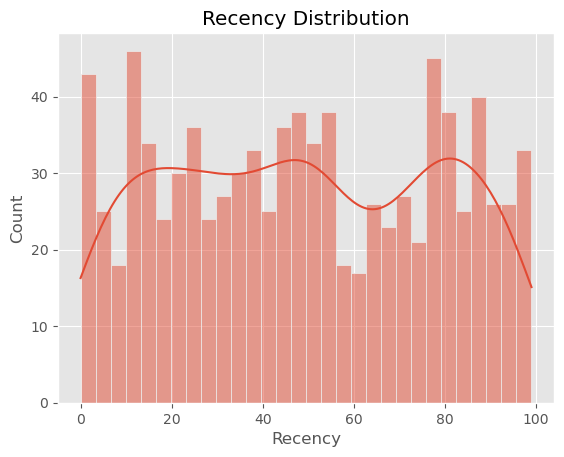

In [171]:
sns.histplot(df['Recency'], kde=True, bins=30)
plt.title("Recency Distribution")
plt.show()

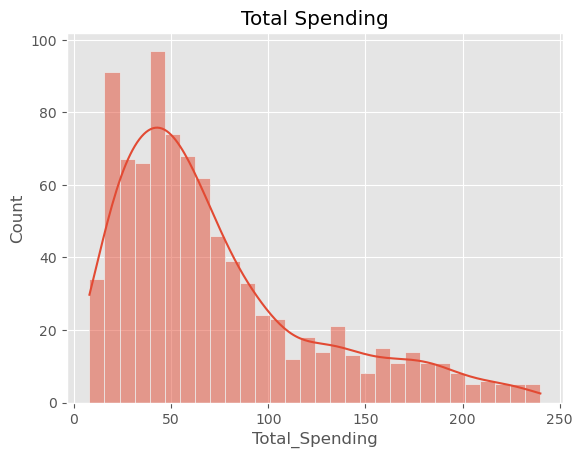

In [172]:
sns.histplot(df['Total_Spending'], kde=True, bins=30)
plt.title("Total Spending")
plt.show()

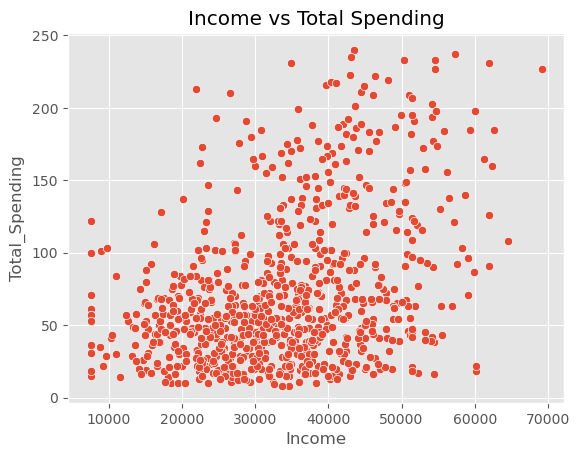

In [173]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title("Income vs Total Spending")
plt.show()

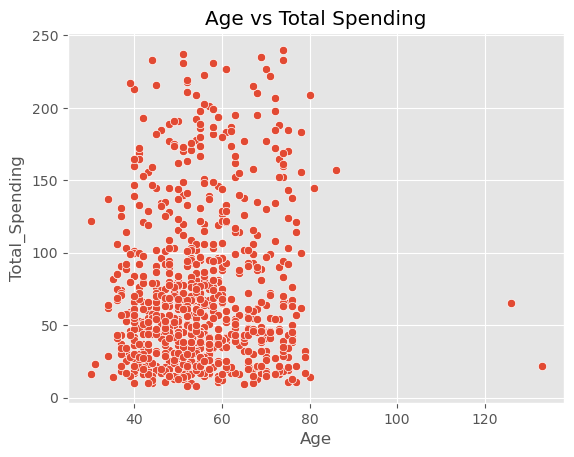

In [174]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.title("Age vs Total Spending")
plt.show()

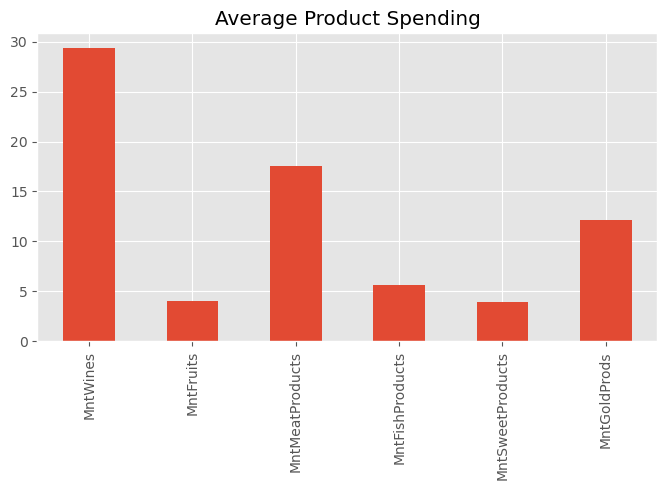

In [175]:
product_cols = ['MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds']

df[product_cols].mean().plot(kind='bar', figsize=(8,4))
plt.title("Average Product Spending")
plt.show()

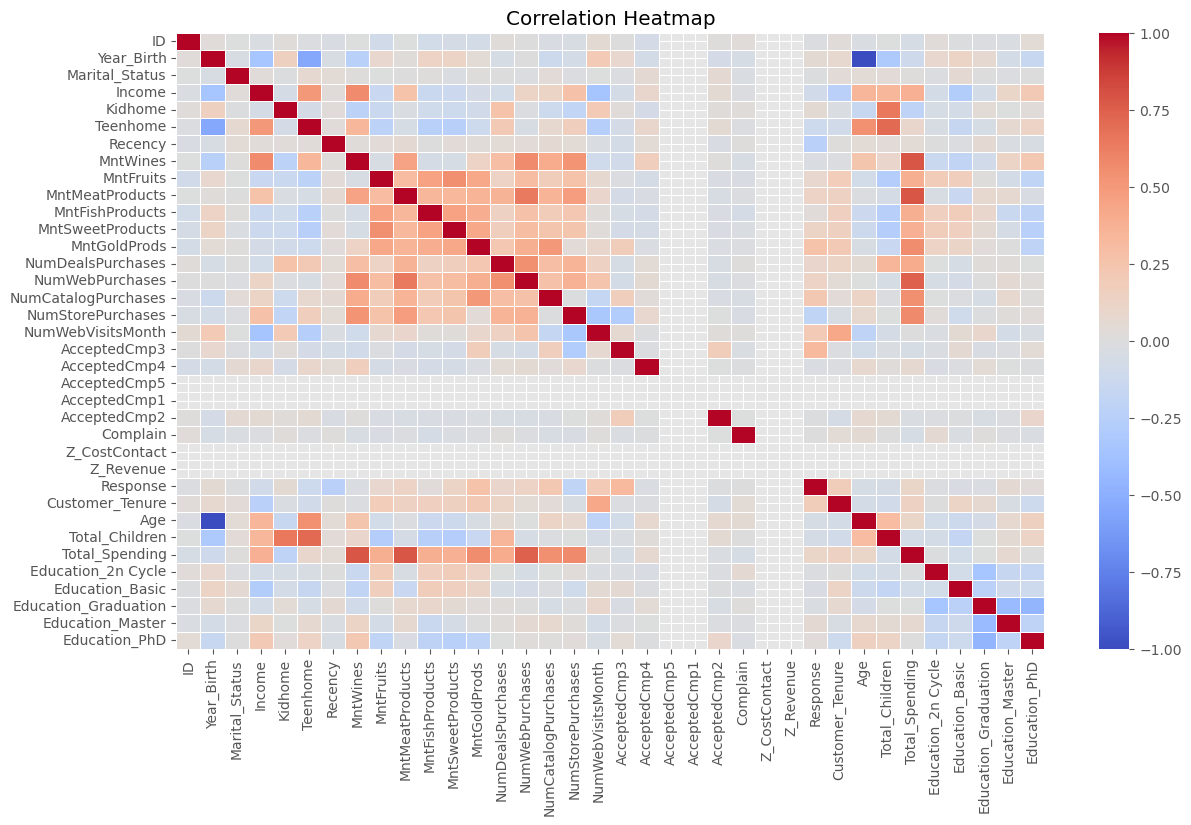

In [176]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

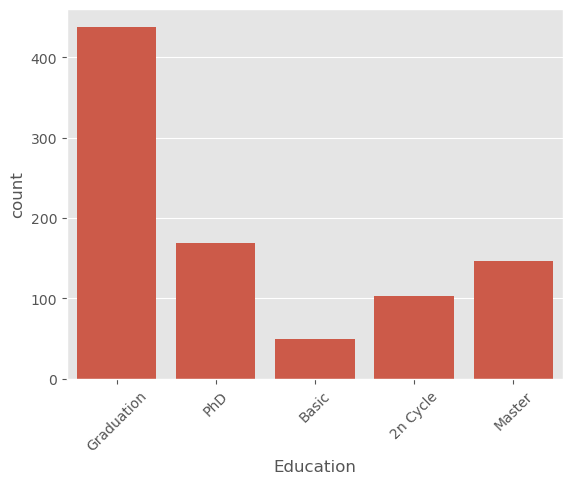

In [177]:
sns.countplot(x='Education', data=df)
plt.xticks(rotation=45)
plt.show()

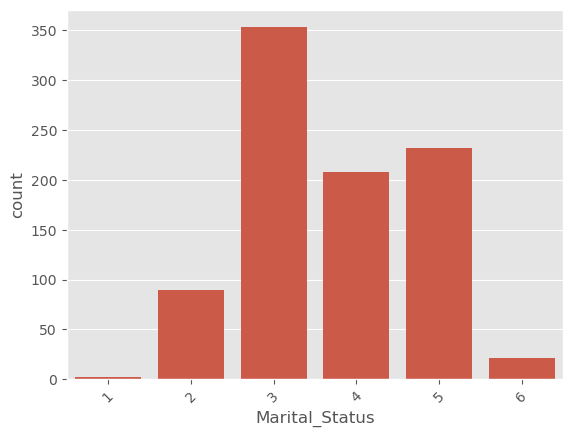

In [178]:
sns.countplot(x='Marital_Status', data=df)
plt.xticks(rotation=45)
plt.show()

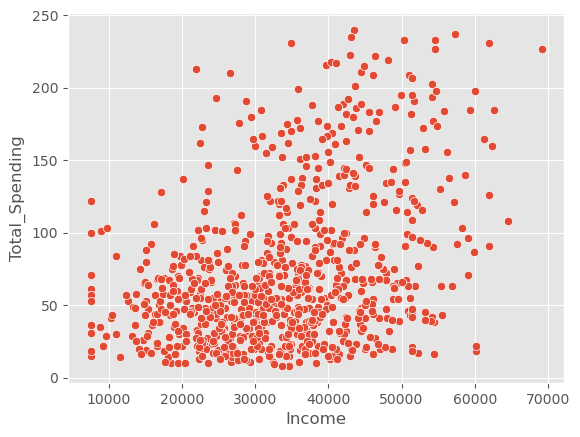

In [179]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.show()

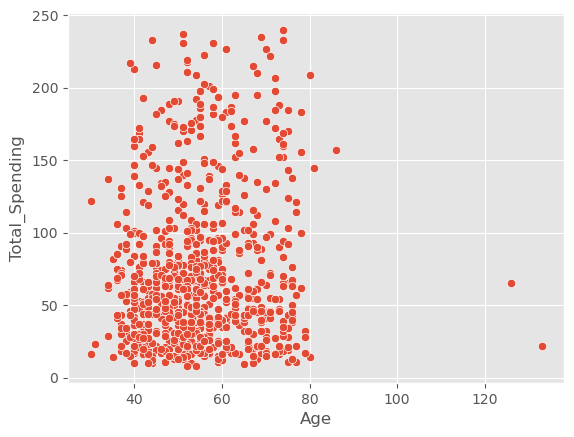

In [180]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.show()

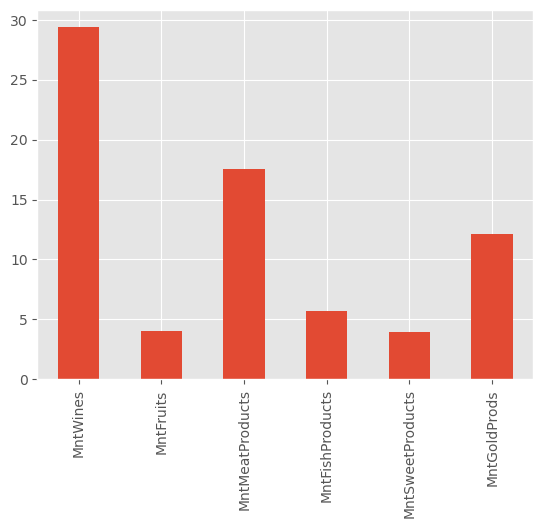

In [181]:
product_cols = ['MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds']

df[product_cols].mean().plot(kind='bar')
plt.show()

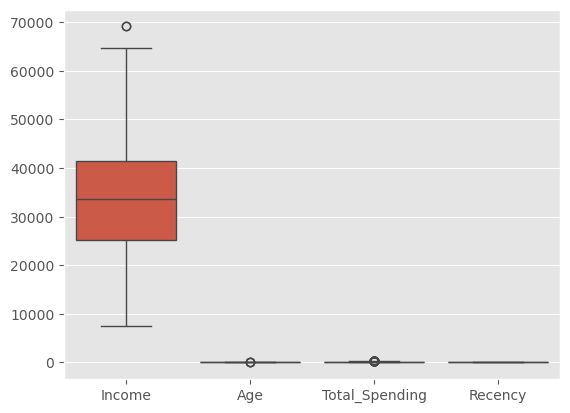

In [182]:
sns.boxplot(data=df[['Income','Age','Total_Spending','Recency']])
plt.show()

In [183]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Customer_Tenure', 'Age', 'Total_Children', 'Total_Spending',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD'],
      dtype='object')

In [184]:
scale_features = ['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[scale_features])
df_scaled = pd.DataFrame(df_scaled, columns=scale_features)
df_scaled.head()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Spending
0,1.090545,-0.558429,-0.518752,-0.721087,-0.524330,-0.588341,-0.530986,0.109127,-0.875753,1.038579,-1.373834,-0.886624,-0.882370
1,-0.608683,-0.558429,-0.008079,0.153234,0.614179,-0.184831,-0.617603,0.109127,0.132420,-0.730129,1.274451,-0.261502,-0.380314
2,-0.021398,1.417412,1.013266,2.401487,-0.382016,-0.588341,0.941510,0.109127,2.148767,-0.730129,1.274451,0.988741,1.859627
3,-0.289075,-0.467237,-0.688976,0.403040,-0.382016,-0.184831,-0.877455,-0.850767,1.140593,-0.730129,-1.373834,1.613863,-0.515483
4,1.525100,-0.740815,0.162145,-0.721087,-0.808957,-0.386586,-0.964072,-0.850767,-0.875753,-0.730129,-1.373834,0.363619,-1.036849


<Axes: >

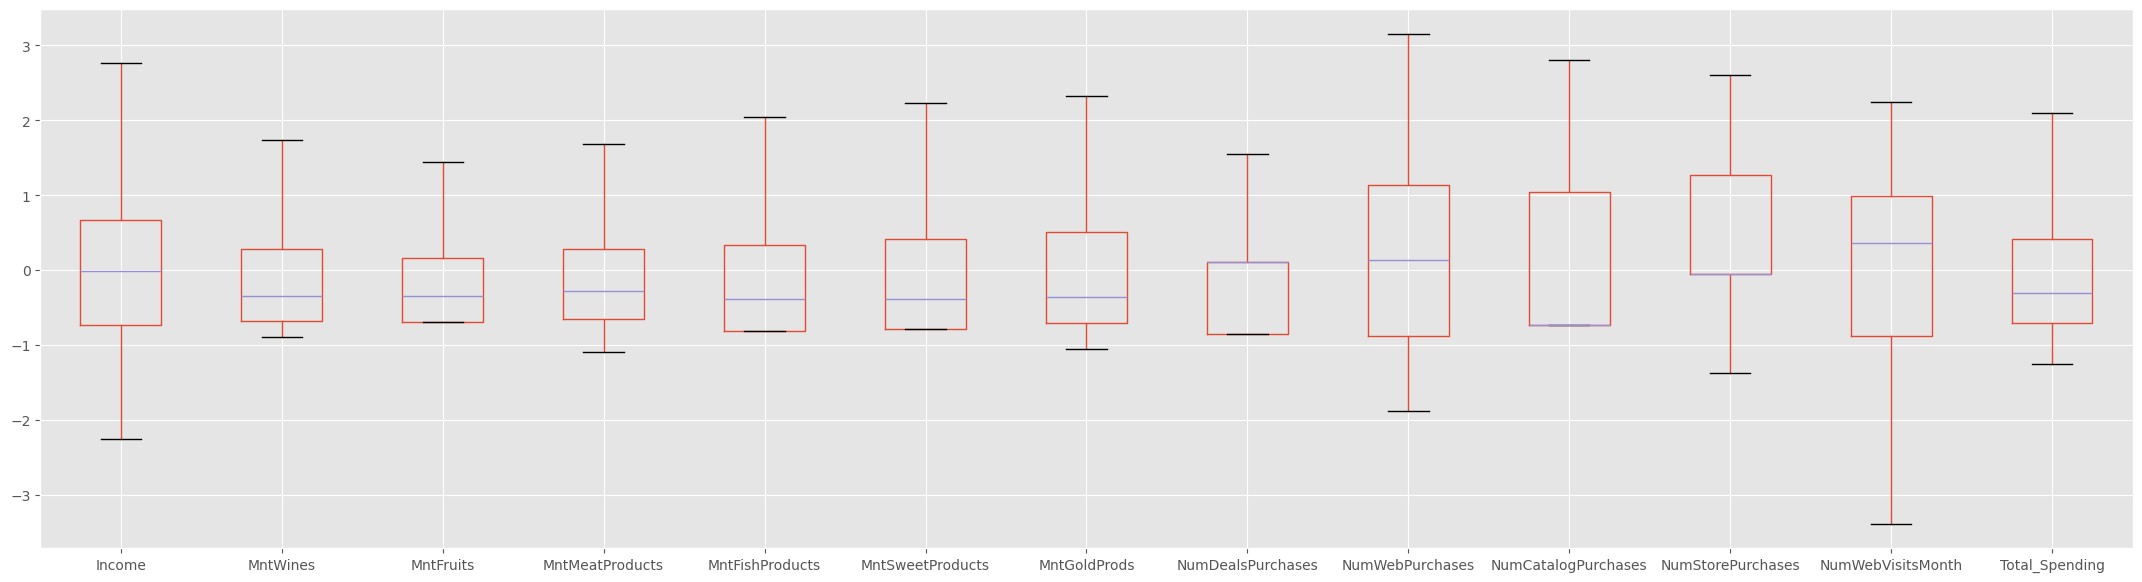

In [201]:
for col in ['Income',  'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending']:
    df = remove_outliers_iqr(df_scaled, col)
plt.figure(figsize=(27,7))
df_scaled.boxplot()

In [208]:
df_scaled.corr()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Spending
Income,1.000000,0.602159,-0.146785,0.269506,-0.169922,-0.137432,-0.070047,-0.085777,0.122498,0.124472,0.272129,-0.356728,0.369124
MntWines,0.602159,1.000000,-0.042094,0.543452,-0.059562,-0.037357,0.149614,0.298568,0.559081,0.397802,0.538032,-0.103965,0.785807
MntFruits,-0.146785,-0.042094,1.000000,0.361604,0.510563,0.595122,0.452621,0.173260,0.329191,0.197206,0.264542,0.045243,0.404950
MntMeatProducts,0.269506,0.543452,0.361604,1.000000,0.357596,0.353574,0.398376,0.389955,0.667490,0.366870,0.499574,0.093177,0.804098
MntFishProducts,-0.169922,-0.059562,0.510563,0.357596,1.000000,0.461783,0.406276,0.165407,0.283224,0.195604,0.230889,0.037528,0.386383
MntSweetProducts,-0.137432,-0.037357,0.595122,0.353574,0.461783,1.000000,0.433286,0.185231,0.303060,0.238396,0.267237,0.004358,0.391348
MntGoldProds,-0.070047,0.149614,0.452621,0.398376,0.406276,0.433286,1.000000,0.252993,0.396008,0.510555,0.041248,0.088258,0.576582
NumDealsPurchases,-0.085777,0.298568,0.173260,0.389955,0.165407,0.185231,0.252993,1.000000,0.558920,0.279345,0.347153,0.130405,0.400970
NumWebPurchases,0.122498,0.559081,0.329191,0.667490,0.283224,0.303060,0.396008,0.558920,1.000000,0.269883,0.370528,0.255835,0.740218
NumCatalogPurchases,0.124472,0.397802,0.197206,0.366870,0.195604,0.238396,0.510555,0.279345,0.269883,1.000000,-0.007846,-0.167743,0.547730
